# Label extraction from radiology reports

Select the **Python (RSNA Knee)** kernel in the top-right before running cells.

Reports exist in train only. The MRI model never sees them at test time. This notebook builds a **report → 12 binary labels** mapper so the ~4,349 unlabeled studies can become silver training data.

**v0 plan (do in order):**
1. Harness: `predict` + `evaluate` on gold (this notebook inits that).
2. Keyword rules, starting with Effusion / Baker's, then ACL (watch negation).
3. Error analysis: print false positives / false negatives for the worst label.
4. Fix one failure class, re-score. Only then consider a heavier model.

Your work starts at the keyword dict inside `predict`. Run the all-zero baseline first so you know the scoreboard works (recall should be 0).

In [28]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("Working directory:", Path.cwd())

Python: 3.11.5
pandas: 3.0.5
Working directory: /Users/paramtully/IdeaProjects/TechnicalProjects/RSNA-Knee-Abnormality-Detection


In [46]:
DATA_DIR = Path(".")

LABELS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]

train = pd.read_csv(DATA_DIR / "train.csv")
gold = train.loc[train[LABELS].notna().all(axis=1)].copy()
unlabeled = train.loc[train[LABELS].isna().all(axis=1)].copy()

print("train:", train.shape)
print("gold:", gold.shape)
print("unlabeled:", unlabeled.shape)
assert gold.shape[0] == 58, gold.shape[0]
assert unlabeled.shape[0] == 4407 - 58, unlabeled.shape[0]

train: (4407, 14)
gold: (58, 14)
unlabeled: (4349, 14)


In [47]:
# define the functions used to evaluate the performance of the label extraction

    # Score a report→label mapper against the 58 gold studies.
    # REQUIRES: pred has all LABELS columns and the same number of rows as gold, in the same order
    # MODIFIES: nothing
    # EFFECTS: displays a per-label scoreboard and an fp-vs-fn bar chart; returns the scoreboard
def evaluate(pred: pd.DataFrame) -> (pd.DataFrame, pd.DataFrame):
    y = gold[LABELS].astype(int)
    p = pred[LABELS].astype(int)
    p.index = y.index

    prec, rec, f1, support = precision_recall_fscore_support(
        y, p, average=None, zero_division=0
    )
    # per label: [[tn, fp], [fn, tp]]
    cms = multilabel_confusion_matrix(y, p)
    scores = pd.DataFrame(
        {
            "support": support.astype(int),
            "tp": cms[:, 1, 1],
            "fp": cms[:, 0, 1],
            "fn": cms[:, 1, 0],
            "precision": prec,
            "recall": rec,
            "f1": f1,
        },
        index=LABELS,
    )
    display(scores)
    print(f"prediction accuracy (all 12 correct): {accuracy_score(y, p):.4f}")
    print(f"macro f1: {f1_score(y, p, average='macro', zero_division=0):.4f}")

    err_counts = scores.reset_index(names="label")[["label", "fp", "fn"]]
    err_long = err_counts.melt(id_vars="label", var_name="error", value_name="count")
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(
        data=err_long,
        x="label",
        y="count",
        hue="error",
        palette={"fp": "#d62728", "fn": "#1f77b4"},
        ax=ax,
    )
    ax.set_title("false positives vs false negatives (higher = worse)")
    ax.set_xlabel("label")
    ax.set_ylabel("count among 58 gold studies")
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    plt.show()
    return y, p

def get_pred(mapper):
    return pd.DataFrame(gold["Report"].map(mapper).tolist(), index=gold.index)


,support,tp,fp,fn,precision,recall,f1
ACL,24,7,14,17,0.333333,0.291667,0.311111
MCL,9,3,14,6,0.176471,0.333333,0.230769
Medial Meniscus,26,12,10,14,0.545455,0.461538,0.500000
Lateral Meniscus,23,11,10,12,0.523810,0.478261,0.500000
Medial OA,15,0,0,15,0.000000,0.000000,0.000000
Lateral OA,11,0,0,11,0.000000,0.000000,0.000000
PF OA,21,0,0,21,0.000000,0.000000,0.000000
Effusion,35,15,13,20,0.535714,0.428571,0.476190
Synovitis,27,6,3,21,0.666667,0.222222,0.333333
Baker's,12,2,6,10,0.250000,0.166667,0.200000


prediction accuracy (all 12 correct): 0.0000
macro f1: 0.2907


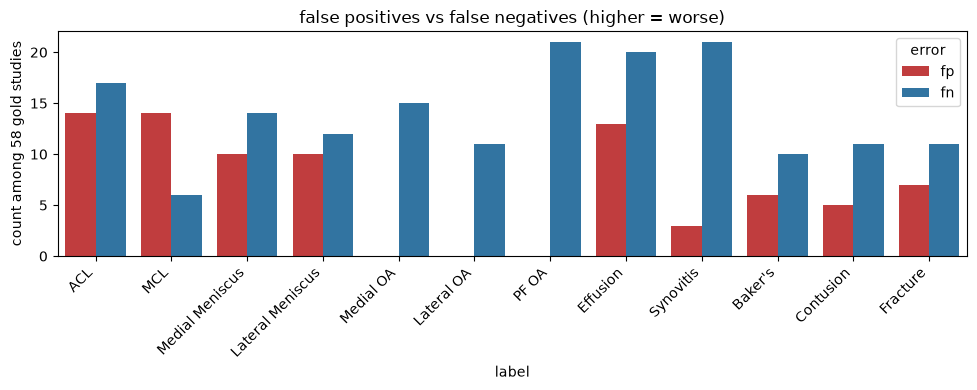

In [48]:
# try simple label search 
def predict_simple_extract(report: str) -> dict:
    text = "" if report is None else str(report).lower()
    return {label: int(label.lower() in text) for label in LABELS}

pred = get_pred(predict_simple_extract)
y, p = evaluate(pred)


Findings:
- there are cases where the label (diagnosed) was not found in the report
    - possible for multiple reasons: annotated vs fully spelled out, different language
- some false positives could be from negations being recorded as diagnoses
- higher false positive rate >> false negative rate because missing an injury is worse for patients

| Pattern | What it usually means | Model needed? |
|---|---|---|
| OA: 0 tp, 0 fp | The string `"medial oa"` almost never appears. Radiologists write osteoarthritis, chondromalacia, *artrosis femorotibial*, etc. | No — wrong search terms |
| ACL: 7 tp, **14 fp**, 17 fn | Mentions are common; many are “ACL intact” / “no ACL tear” *and* many positives use other wording | Maybe a 3–5 word negation window, not BERT |
| Baker's: 2 tp, 6 fp, 10 fn | Apostrophe + English-only (`"baker's"` misses `baker cyst`, `quiste de baker`) | Synonym list |

In [90]:
# look more closely into examples of false positives and false negatives

# get rows with false positives and false negatives
# display(y.head())

fp_acl = gold[(y["ACL"] == 0) & (p["ACL"] == 1)]
fn_acl= gold[(y["ACL"] == 1) & (p["ACL"] == 0)]

fp_acl = fp_acl.loc[:, ["StudyInstanceUID", "Report", "ACL"]]
fn_acl = fn_acl.loc[:, ["StudyInstanceUID", "Report", "ACL"]]

# get occurences of "acl" in the reports
fp_acl["acl_count"] = fp_acl["Report"].str.lower().str.count("acl")
fn_acl["acl_count"] = fn_acl["Report"].str.lower().str.count("acl")


def get_context(report, term="acl", window=5):
    words = str(report).lower().split()
    idxs = [i for i, w in enumerate(words) if term in w]
    return [" ".join(words[max(0, i - window) : i + window + 1]) for i in idxs]

fp_acl["context"] = fp_acl["Report"].map(get_context)
fn_acl["context"] = fn_acl["Report"].map(get_context)

print(f"===== Review of False Positives =====")
display(fp_acl.head(5))
for i, text in enumerate(fp_acl["Report"].head(4), 1):
    print(f"===== FP {i} =====\n{text}\n")

print(f"===== Review of False Negatives =====")
display(fn_acl.head(5))
for i, text in enumerate(fn_acl["Report"].head(3), 1):
    print(f"===== FN {i} =====\n{text}\n")



===== Review of False Positives =====


,StudyInstanceUID,Report,ACL,acl_count,context
63,1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269,The study reveals normal knee joint alignment. No fracture is seen. \n ACL is intact. PCL is preserved. \n ...,0.0,1,[alignment. no fracture is seen. acl is intact. pcl is preserved.]
109,1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Date and Time: [DATE] [TIME]\nIndication: 2 years of pain with walking u...,0.0,1,[cruciate ligaments: anterior cruciate ligament (acl): normal with both bundles intact.]
445,1.2.826.0.1.3680043.8.498.11287937729196958426538087439102017580,"MRI of left Knee with \n-3-Plane Loc R'T, Sag PD FS, AX T2 FS, Sag T2 FS, Sag T1, CORT2 FS\n\n> There is no abnormal...",0.0,1,"[no increased intensity in the acl, mcl and lcl, it appears]"
607,1.2.826.0.1.3680043.8.498.11771393824519892797114773408583976756,"MRI of Knee with \n-Locator, SG PD FatSat, SG T2W FS, SG T1W, CO T2W FS, AX T2W FS\n\n\n\n* High signal in the soft ...",0.0,3,"[* interstitial hyperintense signal of acl, in favor of grade 1, synovitis. > the contour of acl & pcl appear to be,..."
632,1.2.826.0.1.3680043.8.498.11851412923016044948101698015974810604,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Date and Time: [DATE] [TIME]\nIndication: Pain\nComparison: No relevant ...,0.0,1,[cruciate ligaments: anterior cruciate ligament (acl): normal with both bundles intact.]


===== FP 1 =====
 The study reveals normal knee joint alignment.   No fracture is seen.  
   ACL is intact.   PCL is preserved.  
  The MCL is intact.    Medial meniscus is not torn.  
  The FCL, popliteus and biceps femoris tendons are preserved.       
   Horizontal tear at anterior horn of the lateral meniscus is noted.  
   Focal osteochondral defect at lateral patellar facet, about 8x12mm. with subchondral bone edema is detected.   Full thickness cartilage defect, 1.2x1.5cm. at lateral trochlea with subchondral bone edema is noted.   Small osteochondral body, about intact9xintact4cm. at anterior infrapatellar recess is noted.   
  The quadriceps and patellar tendons are preserved.   
   Moderate joint effusion, distended suprapatellar bursa with thickend synovial tissue are observed.  Horizontal tear at anterior horn of the lateral meniscus.  
     Osteochondral fracture at lateral patellar facet, about 8x12mm. with dislodge OCD fragment. 
     Full thickness cartilage defect, 1.2

,StudyInstanceUID,Report,ACL,acl_count,context
470,1.2.826.0.1.3680043.8.498.11382021393803389951964005983002209238,"In the medial compartment, there is longitudinal vertical tear at the body and posterior horn of the medial meniscu...",1.0,0,[]
537,1.2.826.0.1.3680043.8.498.11557620559191469069130827959098335840,Antecedentes Clínicos:\nRodilla traumática aguda.\nHallazgos:\nRotura espesor y ancho total de la unión del tercio m...,1.0,0,[]
869,1.2.826.0.1.3680043.8.498.12505035424093604269515328931488770819,Técnica: RMN de la rodilla. Resultados: Rotura del LCA. Rotura parcial del LCM. Rotura de menisco interno y lateral....,1.0,0,[]
906,1.2.826.0.1.3680043.8.498.12606657226568558340797193167488111973,"In the medial compartment, the meniscus is not torn and there is no focal chondrosis or chondral injury. \n The late...",1.0,0,[]
1172,1.2.826.0.1.3680043.8.498.13335129881737731410081002627729200903,[DATE]: MR Knie Rechts 15ch AA: Klinische inlichtingen: Zie gescande aanvraag Diagnostische vraagstelling: Zie gesca...,1.0,0,[]


===== FN 1 =====
 In the medial compartment, there is longitudinal vertical tear at the body and posterior horn of the medial meniscus. There is no focal chondrosis or chondral injury. 
 The lateral compartment, the meniscus is not torn and there is no focal chondrosis or chondral injury. 
 The patellofemoral joint, the patellar and trochlear cartilage appears congruent without chondral lesion. The medial patellofemoral ligament is intact.  
 In the intercondylar notch, there is complete tear of the anterior cruciate ligament, at mid substance. The posterior cruciate ligament is intact. There is anterior tibial translation.   
 The medial and lateral collateral ligament complexes are intact. The extensor mechanism is normal.  
 No knee effusion is present. The surrounding musculature is normal. There is no fracture or bone contusion.   -- Longitudinal vertical tear at the body and posterior horn of the medial meniscus. 
 -- Complete tear of the anterior cruciate ligament, at mid substa

Findings:
- same findings as earlier: negations, full vs condensed annotation, different languages account for incorrect parsing
- for english: can get full/annotated word/common word context (+/- 5 words) and look for negations (not, normal, intact, etc) and if any has a negation, treat as non injury (or the other way around; I'll have to optimize)
    - regarding common use terms, e.g. meniscus for MCL: I've noticed repeats where the full medical term is used for diagnosing an injury and common terms used for follow-up evaluations that could potentially conflict with an earlier diagnosis.
        - can try ignoring common names for now and potentially add them and compare results
- with regards to other languages, I could find terms from text / outside sources and hardcode them into search terms, or use a multilingual vector of chunks of text to normalize, as first ideas
- additional note: grade 1 injury of acl (sprain) was marked as non injury

**False positives**

| Example | Context | Tag |
|---|---|---|
| FP1 | `acl is intact` | negation / intact |
| FP2, FP5 | `acl: normal … intact` | negation / normal |
| FP3 | `no increased intensity in the acl … normal` | negation |
| FP4 | `grade 1 injury of acl` but gold ACL=0 | not negation — label definition or gold disagreement |

**False negatives** (string `acl` never appears)

| Example | What the report says | Tag |
|---|---|---|
| FN1 | `complete tear of the anterior cruciate ligament` | English synonym, not language |
| FN2, FN3 | `rotura del LCA` | Spanish abbreviation |
| FN table row 5 | Dutch `Knie` | other language |


policy A: mention only


,support,tp,fp,fn,precision,recall,f1
ACL,24,20,23,4,0.465116,0.833333,0.597015
MCL,9,9,28,0,0.243243,1.000000,0.391304
Medial Meniscus,26,18,18,8,0.500000,0.692308,0.580645
Lateral Meniscus,23,18,16,5,0.529412,0.782609,0.631579
Medial OA,15,4,1,11,0.800000,0.266667,0.400000
Lateral OA,11,2,2,9,0.500000,0.181818,0.266667
PF OA,21,6,1,15,0.857143,0.285714,0.428571
Effusion,35,28,19,7,0.595745,0.800000,0.682927
Synovitis,27,9,4,18,0.692308,0.333333,0.450000
Baker's,12,9,11,3,0.450000,0.750000,0.562500


prediction accuracy (all 12 correct): 0.0172
macro f1: 0.5091


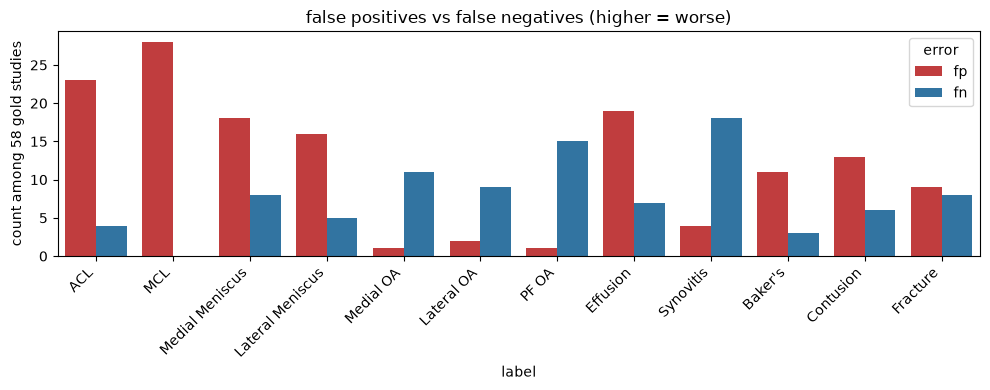

policy B: mention + negation veto


,support,tp,fp,fn,precision,recall,f1
ACL,24,20,13,4,0.606061,0.833333,0.701754
MCL,9,9,14,0,0.391304,1.000000,0.562500
Medial Meniscus,26,17,12,9,0.586207,0.653846,0.618182
Lateral Meniscus,23,16,10,7,0.615385,0.695652,0.653061
Medial OA,15,3,1,12,0.750000,0.200000,0.315789
Lateral OA,11,1,2,10,0.333333,0.090909,0.142857
PF OA,21,5,1,16,0.833333,0.238095,0.370370
Effusion,35,26,12,9,0.684211,0.742857,0.712329
Synovitis,27,9,4,18,0.692308,0.333333,0.450000
Baker's,12,9,10,3,0.473684,0.750000,0.580645


prediction accuracy (all 12 correct): 0.0517
macro f1: 0.5250


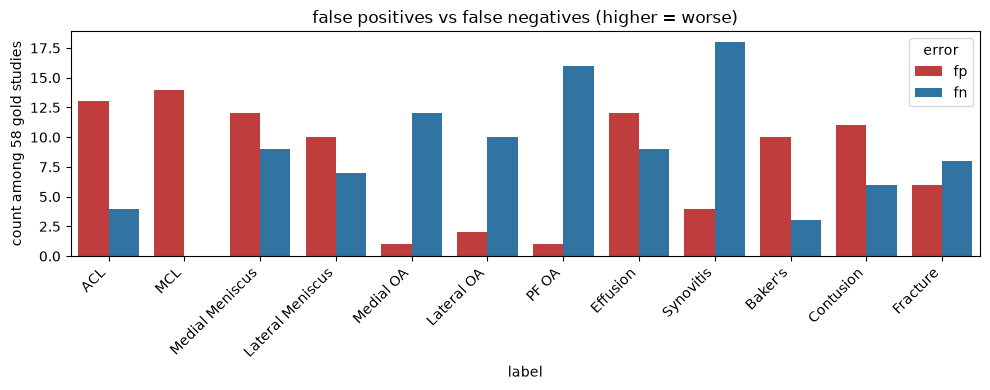

ACL baseline was tp=7 fp=14 fn=17


In [91]:
# try keep a map of synonym keywords and look for occurences and negations
# keywords extracted via llm
label_synonyms = {
    "ACL": {
        "acl",
        "anterior cruciate",
        "lca",
        "ligamento cruzado anterior",
        "ligament croisé antérieur",
        "vkb",
        "voorste kruisband",
        "vorderes kreuzband",
        "ön çapraz",
        "anterior çapraz",
        "предна кръстна",
        "предната кръстна",
        "πρόσθιος χιαστ",
        "πρόσθιου χιαστ",
        "πρόσθιο χιαστό",
        "prednji križni",
        "prednje križne",
        "prednja križna",
    },
    "MCL": {
        "mcl",
        "medial collateral",
        "lcm",
        "ligamento colateral medial",
        "ligament collatéral médial",
        "medial kollateral",
        "iç yan bağ",
        "έσω πλάγιο",
        "έσω πλαγίου",
        "έσω πλάγιος",
        "mediale collaterale",
        "mediales kollateralband",
        "medijalni kolateralni",
        "medijalnog kolateralnog",
        "медиален колатерален",
    },
    "Medial Meniscus": {
        "medial meniscus",
        "medial meniscal",
        "medial menisküs",
        "menisco interno",
        "menisco medial",
        "menisco interno y lateral",
        "mediale meniscus",
        "innenmeniskus",
        "медиален менискус",
        "медиалния менискус",
        "έσω μηνίσκο",
        "έσω μηνίσκου",
        "έσω μηνίσκος",
        "ménisque médial",
        "ménisque interne",
        "medijalnog meniskusa",
    },
    "Lateral Meniscus": {
        "lateral meniscus",
        "lateral meniscal",
        "lateral menisküs",
        "menisco lateral",
        "menisco externo",
        "menisco interno y lateral",
        "laterale meniscus",
        "außenmeniskus",
        "латерален менискус",
        "латералния менискус",
        "έξω μηνίσκο",
        "έξω μηνίσκου",
        "έξω μηνίσκος",
        "ménisque latéral",
        "lateralnog meniskusa",
        "lateralni meniskus",
    },
    "Medial OA": {
        "medial oa",
        "oa of medial",
        "oa of medial compartment",
        "oa of all three",
        "artrosis femorotibial medial",
        "oa femorotibial medial",
        "tricompartmental osteoarthritis",
        "mediale gonarthrose",
        "kraakbeenlijden mediaal",
    },
    "Lateral OA": {
        "lateral oa",
        "oa of lateral",
        "oa of all three",
        "artrosis femorotibial lateral",
        "oa femorotibial lateral",
        "tricompartmental osteoarthritis",
    },
    "PF OA": {
        "pf oa",
        "patellofemoral osteoarthritis",
        "patellofemoral oa",
        "oa patelofemoral",
        "oa of all three",
        "oa pf",
        "condropatía rotuliana",
        "chondromalacia patella",
        "tricompartmental osteoarthritis",
        "patellofemorale artrose",
    },
    "Effusion": {
        "effusion",
        "derrame",
        "hydrops",
        "излив",
        "ставен излив",
        "συλλογή υγρού",
        "ενδαρθρική συλλογή",
        "efüzyon",
        "épanchement",
        "gelenkerguss",
        "gewrichtsvocht",
        "izljev",
        "zglobni izljev",
        "hemarthros",
        "hemartrosis",
    },
    "Synovitis": {
        "synovitis",
        "sinovitis",
        "synovite",
        "sinovit",
        "θυλακίτιδα",
        "synovial thickening",
        "hypertrophy of the synovium",
        "синовит",
        "synovialitis",
    },
    "Baker's": {
        "baker's",
        "baker",
        "bakers",
        "popliteal cyst",
        "quiste de baker",
        "quiste poplíteo",
        "kyste de baker",
        "kyste poplité",
        "bakerse",
        "baker-zyste",
        "bakerzyste",
        "κύστη baker",
        "baker kisti",
        "bakerova",
        "poplitealna cista",
        "бейкър",
    },
    "Contusion": {
        "contusion",
        "contusión",
        "contusiones",
        "bone bruise",
        "botcontusie",
        "botoedeem",
        "kontüzyon",
        "kemik kontüzyonu",
        "костно-мозъчен едем",
        "контуз",
        "μώλωπ",
        "οστικό μώλωπα",
        "knochenmarksödem",
        "knochenmarködem",
        "koštani edem",
        "contusion osseuse",
        "edema óseo",
        "kontuzija",
    },
    "Fracture": {
        "fracture",
        "fractura",
        "fractuur",
        "fraktur",
        "фрактура",
        "kırık",
        "kırığı",
        "κάταγμα",
        "impactiefractuur",
        "fraktura",
        "insufficiency fracture",
        "subkondral kırık",
    },
}

# keep negations. Token match only — skip "no"/"not" (bind to the previous
# sentence) and "grade 1" (one gold disagreement, not a negation cue).
negations = {"intact", "normal", "preserved", "without"}
NEGATION_WINDOW = 5
_PUNCT = ".,;:()[]*<>'\""


# returns lowercased tokens; empty strings after strip are dropped
def _tokens(text: str) -> list[str]:
    return [w.strip(_PUNCT) for w in str(text).lower().split() if w.strip(_PUNCT)]


# Find synonym mentions and the ±window tokens around each hit.
def get_context(report: str, terms: set[str], window: int = NEGATION_WINDOW) -> list[str]:
    words = _tokens("" if report is None else report)
    contexts = []
    for term in terms:
        term_toks = _tokens(term)
        n = len(term_toks)
        if n == 0:
            continue
        for i in range(len(words) - n + 1):
            if words[i : i + n] != term_toks:
                continue
            lo = max(0, i - window)
            hi = min(len(words), i + n + window)
            contexts.append(" ".join(words[lo:hi]))
    return contexts

# Check a single mention window for a negation token.
def has_negation(context: str, negation_set: set[str]) -> bool:
    return any(tok in negation_set for tok in context.split())

# Turn mention windows into a 0/1 label.
# EFFECTS: 0 if there are no mentions; else 1 if use_negation is False;
    #          else 1 iff at least one mention window has no negation token
def _positive_from_contexts(contexts: list[str], use_negation: bool) -> int:
    if not contexts:
        return 0
    if not use_negation:
        return 1
    return int(any(not has_negation(ctx, negations) for ctx in contexts))

# Policy A: any synonym mention counts as positive.
# EFFECTS: returns label -> 1 if any synonym appears, else 0
def predict_mention_only(report: str) -> dict:
    return {
        label: _positive_from_contexts(get_context(report, terms), use_negation=False)
        for label, terms in label_synonyms.items()
    }

# Policy B: synonym mention, unless every mention is negated.
# EFFECTS: returns label -> 1 if some mention window contains no negation
#          token, else 0 (including no mention)
def predict_from_keywords_negations(report: str) -> dict:
    return {
        label: _positive_from_contexts(get_context(report, terms), use_negation=True)
        for label, terms in label_synonyms.items()
    }


print("policy A: mention only")
y, p = evaluate(get_pred(predict_mention_only))
print("policy B: mention + negation veto")
y, p = evaluate(get_pred(predict_from_keywords_negations))
print("ACL baseline was tp=7 fp=14 fn=17")
